In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [ ]:
#use momentum to detect sudden volatility in the market
def calculate_momentum(data, window):
    data['Momentum'] = data['close'] - data['close'].shift(window)
    return data

# Plot Momentum
def plot_momentum(data):
    plt.figure(figsize=(12, 8))
    plt.plot(data['Momentum'], label='Momentum', linewidth=2)
    plt.title('Momentum')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Load your CSV file
csv_file_path = 'btcusdt_1h.csv'
df = pd.read_csv(csv_file_path, parse_dates=['datetime'], index_col='datetime')

# Set the Momentum parameter
window_size = 10 # Adjust this parameter based on your strategy

# Calculate Momentum
df = calculate_momentum(df, window_size)

# Plot the chart
plot_momentum(df)


RSI

In [39]:
class RSIBase():

    def __init__(self, start, end, amount):
        self.symbol = "BTC-USD"
        self.start = start
        self.end = end
        self.initial_balance = amount
        self.current_balance = amount
        self.units = 0
        self.get_data()

    def get_data(self):
        raw = pd.read_csv("btcusdt_1h.csv", parse_dates = ["datetime"], index_col = "datetime").dropna()
        raw.drop(columns=["open","high","low"], inplace = True)
        raw = raw.loc[self.start:self.end]
        raw["buy_n_hold_returns"] = np.log(raw.close / raw.close.shift(1))
        raw["Gains"] = np.where(raw.close.shift(1) - raw.close > 0, raw.close.shift(1) - raw.close, 0)
        raw["Loses"] = np.where(raw.close.shift(1) - raw.close < 0, raw.close - raw.close.shift(1), 0)
        self.data = raw

    def plot_data(self, cols = None):
        self.data["close"].plot(figsize = (12, 8), title = self.symbol)

    def plot_RSI(self, cols = None):
        self.data["RSI_Value"].plot(figsize = (12, 8), title = self.symbol)

    def get_values(self, bar):
        date = str(self.data.index[bar].date())
        price = round(self.data.close.iloc[bar], 5)
        return date, price

    def print_current_balance(self, bar):
        date, price = self.get_values(bar)
        print("{} | Current Balance: {}".format(date, round(self.current_balance, 2)))

    def buy_instrument(self, bar, units = None, amount = None):
        date, price = self.get_values(bar)
        if amount is not None:
            units = int(amount / price)
        self.current_balance -= units * price
        self.units += units

    def sell_instrument(self, bar, units = None, amount = None):
        date, price = self.get_values(bar)
        if amount is not None:
            units = int(amount / price)
        self.current_balance += units * price
        self.units -= units

    def close_pos(self, bar):
        date, price = self.get_values(bar)
        self.current_balance += self.units * price
        self.units = 0
        perf = (self.current_balance - self.initial_balance) / self.initial_balance * 100
        self.print_current_balance(bar)
        print("{} | net performance (%) = {}".format(date, round(perf, 2) ))

    def plot_results(self):
        if self.results is None:
            print("Run test_strategy() first.")
        else:
            title = "{} | RSI Indicator with look-back period of {}. ".format(self.symbol, "14 hours")
            self.results[["creturns", "cstrategy_returns","max_strategy_returns"]].plot(title=title, figsize=(12, 8))


class RSIAction(RSIBase):

    def go_long(self, bar, units = None, amount = None):
        if self.position == -1:
            self.buy_instrument(bar, units = -self.units) # if short position, go neutral first
        if units:
            self.buy_instrument(bar, units = units)
        elif amount:
            if amount == "all":
                amount = self.current_balance
            self.buy_instrument(bar, amount = amount) # go long

    def go_short(self, bar, units = None, amount = None):
        if self.position == 1:
            self.sell_instrument(bar, units = self.units) # if long position, go neutral first
        if units:
            self.sell_instrument(bar, units = units)
        elif amount:
            if amount == "all":
                amount = self.current_balance
            self.sell_instrument(bar, amount = amount)

    def test_rsi_strategy(self, look_back):

        self.position = 0
        self.current_balance = self.initial_balance
        self.get_data()

        self.data["cGains"] = self.data["Gains"].rolling(look_back).sum()
        self.data["cLoses"] = self.data["Loses"].rolling(look_back).sum()
        self.data["RSI_Value"] = 100 - (100/(1+(self.data["cGains"]/self.data["cLoses"])))
        self.data.dropna(inplace = True)

        data = self.data.copy().dropna()
        for bar in range(len(data)-1):
            if data["RSI_Value"].iloc[bar] <= 12.5:                                      # RSI : [0,12.5]    <=> GO SHORT
                data.at[self.data.index[bar],"position"] = -1
            elif data["RSI_Value"].iloc[bar] <= 25:                                      # RSI : [12.5,25]   <=> GO LONG
                data.at[self.data.index[bar],"position"] = 1
            elif data["RSI_Value"].iloc[bar] >= 87.5:                                    # RSI : [87.5,100]  <=> GO LONG
                data.at[self.data.index[bar],"position"] = 1
            elif data["RSI_Value"].iloc[bar] >= 75:                                      # RSI : [75,87.5]   <=> GO LONG
                data.at[self.data.index[bar],"position"] = -1
            elif data["RSI_Value"].iloc[bar] < 75 and data["RSI_Value"].iloc[bar] > 25:  # RSI : [25,75]     <=> GO NEUTRAL
                data.at[self.data.index[bar],"position"] = 0
        data["strategy_returns"] = data["position"].shift(1) * data["buy_n_hold_returns"]
        data.dropna(inplace=True)
        data["creturns"] = data["buy_n_hold_returns"].cumsum().apply(np.exp)
        data["cstrategy_returns"] = data["strategy_returns"].cumsum().apply(np.exp)
        data["max_strategy_returns"] = data["cstrategy_returns"].cummax()
        self.results = data

        for bar in range(len(self.data)-1): # all bars (except the last bar)
            if self.position == 0:
                if self.data["RSI_Value"].iloc[bar] <= 12.5:
                    self.go_short(bar, amount = "all")
                    self.position = -1
                elif self.data["RSI_Value"].iloc[bar] < 25:
                    self.go_long(bar, amount = "all")
                    self.position = 1
                elif self.data["RSI_Value"].iloc[bar] >= 87.5:
                    self.go_long(bar, amount = "all")
                    self.position = 1
                elif self.data["RSI_Value"].iloc[bar] >= 75:
                    self.go_short(bar, amount = "all")
                    self.position = -1
            elif self.position == 1:
                if (self.data["RSI_Value"].iloc[bar] >= 75 and self.data["RSI_Value"].iloc[bar] < 87.5) or (self.data["RSI_Value"].iloc[bar] <= 12.5):
                        self.go_short(bar, amount = "all")
                        self.position = -1
                elif self.data["RSI_Value"].iloc[bar] > 25 and self.data["RSI_Value"].iloc[bar] < 75:
                        self.sell_instrument(bar, units = self.units)
                        self.position = 0
            elif self.position == -1:
                if (self.data["RSI_Value"].iloc[bar] < 25 and self.data["RSI_Value"].iloc[bar] >= 12.5) or (self.data["RSI_Value"].iloc[bar] >= 87.5):
                    self.go_long(bar, amount = "all")
                    self.position = 1
                elif self.data["RSI_Value"].iloc[bar] > 25 and self.data["RSI_Value"].iloc[bar] < 75:
                    self.buy_instrument(bar, units = -self.units)
                    self.position = 0
        self.close_pos(bar+1) # close position at the last bar

In [40]:
tester = RSIAction("2018-01-01", "2022-12-31", 100000)

In [41]:
tester.data

,close,volume,buy_n_hold_returns,Gains,Loses
datetime,,,,,
2018-01-01 05:30:00,13529.01,443.356199,NaN,0.00,0.00
2018-01-01 06:30:00,13203.06,383.697006,-0.024388,325.95,0.00
2018-01-01 07:30:00,13330.18,429.064572,0.009582,0.00,127.12
2018-01-01 08:30:00,13410.03,420.087030,0.005972,0.00,79.85
2018-01-01 09:30:00,13601.01,340.807329,0.014141,0.00,190.98
...,...,...,...,...,...
2022-01-12 01:30:00,42800.38,1219.601780,-0.004003,171.67,0.00
2022-01-12 02:30:00,42659.20,702.103800,-0.003304,141.18,0.00
2022-01-12 03:30:00,42713.13,561.859930,0.001263,0.00,53.93


In [42]:
tester.test_rsi_strategy(14)
def

2022-01-12 | Current Balance: 275165.85
2022-01-12 | net performance (%) = 175.17


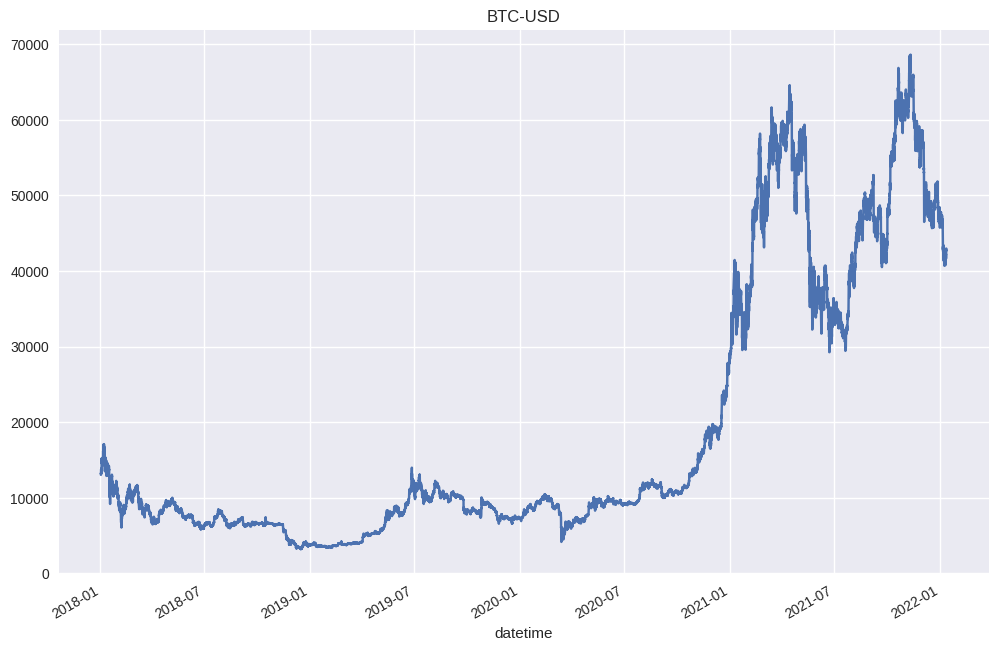

In [43]:
tester.plot_data()

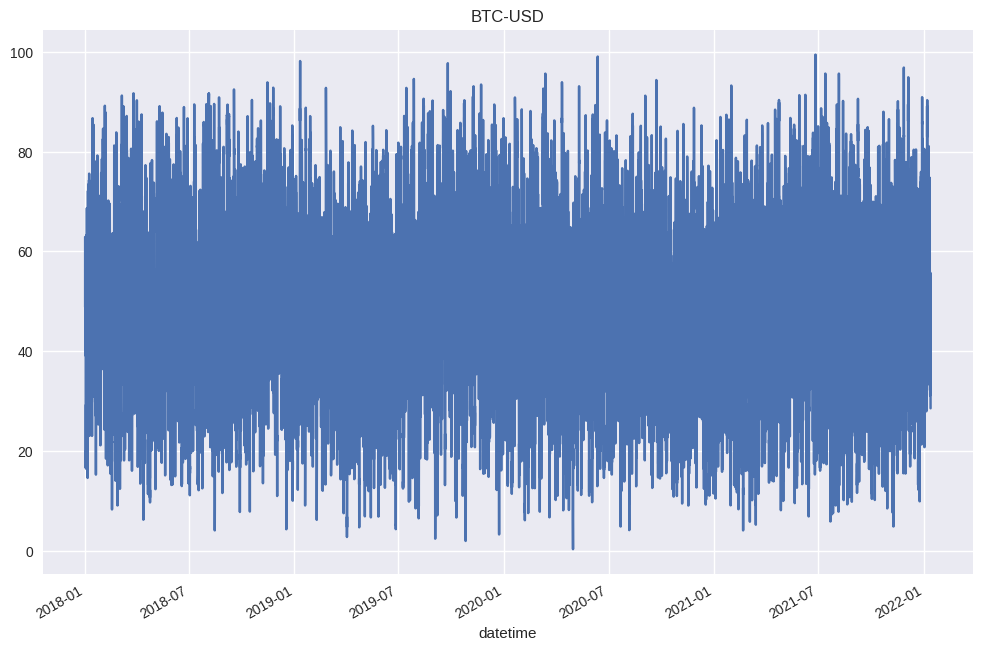

In [44]:
tester.plot_RSI()

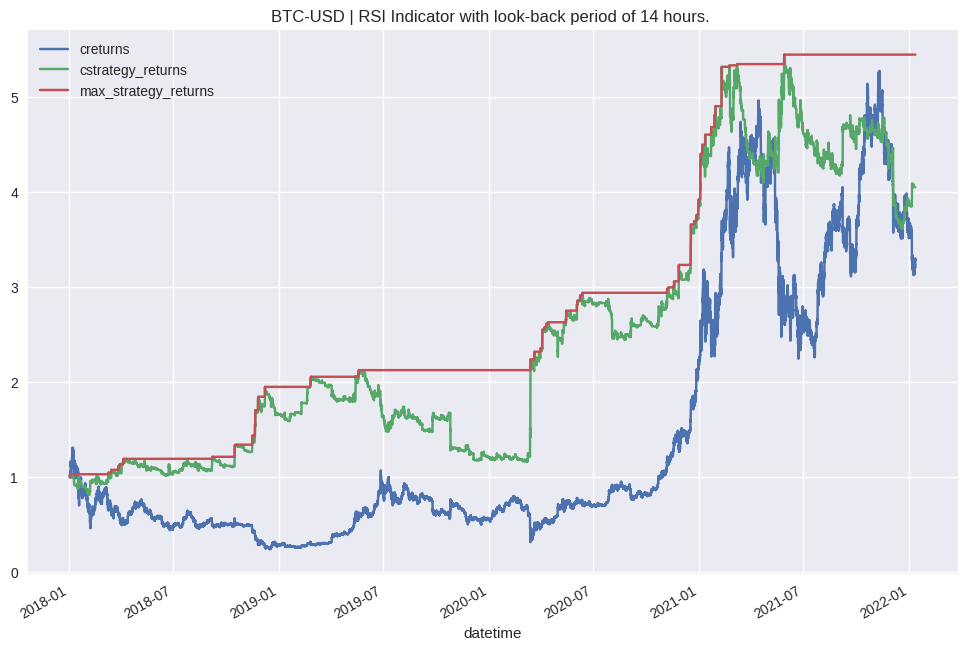

In [45]:
tester.plot_results()

In [46]:
((tester.results["max_strategy_returns"][-1]-tester.results["cstrategy_returns"][-1])/tester.results["max_strategy_returns"][-1])*100

/tmp/ipykernel_8505/51078057.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ((tester.results["max_strategy_returns"][-1]-tester.results["cstrategy_returns"][-1])/tester.results["max_strategy_returns"][-1])*100


25.59448808543479

STOCHASTIC OSCILLATOR

In [47]:
import pandas as pd
import numpy as np

class StochasticOscillatorBase():

    def __init__(self, start, end, amount):
        self.symbol = "BTC-USD"
        self.start = start
        self.end = end
        self.initial_balance = amount
        self.current_balance = amount
        self.units = 0 
        self.get_data()

    def get_data(self):
        raw = pd.read_csv("btcusdt_1h.csv", parse_dates=["datetime"], index_col="datetime").dropna()
        raw.drop(columns=["open", "high", "low"], inplace=True)
        raw = raw.loc[self.start:self.end]
        raw["buy_n_hold_returns"] = np.log(raw.close / raw.close.shift(1))
        raw["Gains"] = np.where(raw.close.shift(1) - raw.close > 0, raw.close.shift(1) - raw.close, 0)
        raw["Loses"] = np.where(raw.close.shift(1) - raw.close < 0, raw.close - raw.close.shift(1), 0)
        self.data = raw

    def plot_data(self, cols=None):
        self.data["close"].plot(figsize=(12, 8), title=self.symbol)

    def plot_stochastic_oscillator(self, cols=None):
        self.data["%K"].plot(figsize=(12, 8), title=self.symbol)

    def get_values(self, bar):
        date = str(self.data.index[bar].date())
        price = round(self.data.close.iloc[bar], 5)
        return date, price

    def print_current_balance(self, bar):
        date, price = self.get_values(bar)
        print("{} | Current Balance: {}".format(date, round(self.current_balance, 2)))

    def buy_instrument(self, bar, units=None, amount=None):
        date, price = self.get_values(bar)
        if amount is not None:
            units = int(amount / price)
        self.current_balance -= units * price
        self.units += units

    def sell_instrument(self, bar, units=None, amount=None):
        date, price = self.get_values(bar)
        if amount is not None:
            units = int(amount / price)
        self.current_balance += units * price
        self.units -= units

    def close_pos(self, bar):
        date, price = self.get_values(bar)
        self.current_balance += self.units * price
        self.units = 0
        perf = (self.current_balance - self.initial_balance) / self.initial_balance * 100
        self.print_current_balance(bar)
        print("{} | net performance (%) = {}".format(date, round(perf, 2)))

    def plot_results(self):
        if self.results is None:
            print("Run test_strategy() first.")
        else:
            title = "{} | Stochastic Oscillator Indicator with k_period = {} and d_period = {}. ".format(self.symbol, "14 hours", "3 hours")
            self.results[["creturns", "cstrategy_returns", "max_strategy_returns"]].plot(title=title, figsize=(12, 8))
            

class StochasticOscillatorAction(StochasticOscillatorBase):

    def go_long(self, bar, units=None, amount=None):
        if self.position == -1:
            self.buy_instrument(bar, units=-self.units)  # if short position, go neutral first
        if units:
            self.buy_instrument(bar, units=units)
        elif amount:
            if amount == "all":
                amount = self.current_balance
            self.buy_instrument(bar, amount=amount)  # go long

    def go_short(self, bar, units=None, amount=None):
        if self.position == 1:
            self.sell_instrument(bar, units=self.units)  # if long position, go neutral first
        if units:
            self.sell_instrument(bar, units=units)
        elif amount:
            if amount == "all":
                amount = self.current_balance
            self.sell_instrument(bar, amount=amount)

    def test_stochastic_oscillator_strategy(self, k_period, d_period):
        self.position = 0
        self.current_balance = self.initial_balance
        self.get_data()

        self.data["%K"] = (self.data["close"] - self.data["close"].rolling(window=k_period).min()) / (
                self.data["close"].rolling(window=k_period).max() - self.data["close"].rolling(window=k_period).min()) * 100
        self.data["%D"] = self.data["%K"].rolling(window=d_period).mean()
        self.data.dropna(inplace=True)

        data = self.data.copy().dropna()
        for bar in range(1,len(data) - 1):
            if data["%K"].iloc[bar] < data["%D"].iloc[bar] and data["%K"].iloc[bar - 1] >= data["%D"].iloc[bar - 1]:
                # Stochastic cross below %D, and previously it was above or equal. Go Short.
                data.at[data.index[bar], "position"] = -1
            elif data["%K"].iloc[bar] > data["%D"].iloc[bar] and data["%K"].iloc[bar - 1] <= data["%D"].iloc[bar - 1]:
                # Stochastic cross above %D, and previously it was below or equal. Go Long.
                data.at[data.index[bar], "position"] = 1
            else:
                # No cross, maintain the current position.
                data.at[data.index[bar], "position"] = 0

        data["strategy_returns"] = data["position"].shift(1) * data["buy_n_hold_returns"]
        data.dropna(inplace=True)
        data["creturns"] = data["buy_n_hold_returns"].cumsum().apply(np.exp)
        data["cstrategy_returns"] = data["strategy_returns"].cumsum().apply(np.exp)
        data["max_strategy_returns"] = data["cstrategy_returns"].cummax()
        self.results = data

        for bar in range(len(data) - 1):  # all bars (except the last bar)
            if self.position == 0:
                if data["%K"].iloc[bar] < data["%D"].iloc[bar] and data["%K"].iloc[bar - 1] >= data["%D"].iloc[
                    bar - 1]:  # Stochastic cross below %D
                    self.go_short(bar, amount="all")
                    self.position = -1
                elif data["%K"].iloc[bar] > data["%D"].iloc[bar] and data["%K"].iloc[bar - 1] <= data["%D"].iloc[
                    bar - 1]:  # Stochastic cross above %D
                    self.go_long(bar, amount="all")
                    self.position = 1
            elif self.position == 1:
                if data["%K"].iloc[bar] < data["%D"].iloc[bar] and data["%K"].iloc[bar - 1] >= data["%D"].iloc[
                    bar - 1]:  # Stochastic cross below %D
                    self.go_short(bar, amount="all")
                    self.position = -1
                elif data["%K"].iloc[bar] > 20 and data["%K"].iloc[bar] < 80:
                    # Stochastic between 20 and 80, maintain the long position.
                    pass
                else:
                    self.sell_instrument(bar, units=self.units)
                    self.position = 0
            elif self.position == -1:
                if data["%K"].iloc[bar] > data["%D"].iloc[bar] and data["%K"].iloc[bar - 1] <= data["%D"].iloc[
                    bar - 1]:  # Stochastic cross above %D
                    self.go_long(bar, amount="all")
                    self.position = 1
                elif data["%K"].iloc[bar] > 20 and data["%K"].iloc[bar] < 80:
                    # Stochastic between 20 and 80, maintain the short position.
                    pass
                else:
                    self.buy_instrument(bar, units=-self.units)
                    self.position = 0

        self.close_pos(bar + 1)  # close position at the last bar


In [48]:
tester = StochasticOscillatorAction("2018-01-01", "2022-12-31", 100000)

In [49]:
tester.data

,close,volume,buy_n_hold_returns,Gains,Loses
datetime,,,,,
2018-01-01 05:30:00,13529.01,443.356199,NaN,0.00,0.00
2018-01-01 06:30:00,13203.06,383.697006,-0.024388,325.95,0.00
2018-01-01 07:30:00,13330.18,429.064572,0.009582,0.00,127.12
2018-01-01 08:30:00,13410.03,420.087030,0.005972,0.00,79.85
2018-01-01 09:30:00,13601.01,340.807329,0.014141,0.00,190.98
...,...,...,...,...,...
2022-01-12 01:30:00,42800.38,1219.601780,-0.004003,171.67,0.00
2022-01-12 02:30:00,42659.20,702.103800,-0.003304,141.18,0.00
2022-01-12 03:30:00,42713.13,561.859930,0.001263,0.00,53.93


In [50]:
tester.test_stochastic_oscillator_strategy(14,3)

2022-01-12 | Current Balance: 3398.83
2022-01-12 | net performance (%) = -96.6


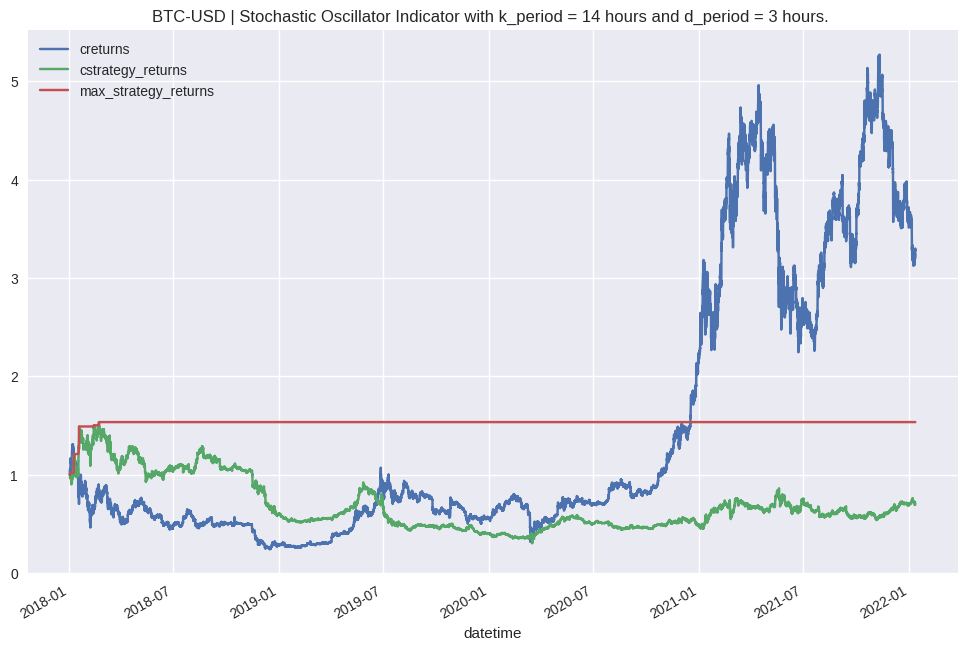

In [51]:
tester.plot_results()

BOLLINGER BANDS

In [52]:
class BB_Base():

    def __init__(self, start, end, amount):
        self.symbol = "BTC-USD"
        self.start = start
        self.end = end
        self.initial_balance = amount
        self.current_balance = amount
        self.units = 0 
        self.get_data()

    def get_data(self):
        raw = pd.read_csv("btcusdt_1h.csv", parse_dates = ["datetime"], index_col = "datetime").dropna()
        raw.drop(columns=["open","high","low"], inplace = True)
        raw = raw.loc[self.start:self.end]
        raw["buy_n_hold_returns"] = np.log(raw.close / raw.close.shift(1))
        self.data = raw

    def plot_data(self, cols = None):  
        if cols is None:
            cols = ["close","SMA","Lower","Upper"]
        #change colors to blue for upper bollinger band, red for lower bollinger band
        #black for SMA, green for close price
        self.data[cols].plot(figsize=(12, 8), color=["blue","red","black","green"], title="Bollinger Bands")
    
    def get_values(self, bar):
        date = str(self.data.index[bar].date())
        price = round(self.data.close.iloc[bar], 5)
        return date, price
    
    def print_current_balance(self, bar):
        date, price = self.get_values(bar)
        print("{} | Current Balance: {}".format(date, round(self.current_balance, 2)))
        
    def buy_instrument(self, bar, units = None, amount = None):
        date, price = self.get_values(bar)
        if amount is not None: 
            units = int(amount / price)
        self.current_balance -= units * price 
        self.units += units
    
    def sell_instrument(self, bar, units = None, amount = None):
        date, price = self.get_values(bar)
        if amount is not None: 
            units = int(amount / price)
        self.current_balance += units * price
        self.units -= units
        
    def close_pos(self, bar):
        date, price = self.get_values(bar)
        self.current_balance += self.units * price
        self.units = 0
        perf = (self.current_balance - self.initial_balance) / self.initial_balance * 100
        self.print_current_balance(bar)
        print("{} | net performance (%) = {}".format(date, round(perf, 2) ))
        
    def plot_results(self):
        if self.results is None:
            print("Run test_strategy() first.")
        else:
            title = "{} | Bollinger Bands with standard deviation of +-2 away from SMA. ".format(self.symbol)
            self.results[["creturns", "cstrategy_returns","max_strategy_returns"]].plot(title=title, figsize=(12, 8))
        
    
        
class BB_Action(BB_Base):

    def go_long(self, bar, units = None, amount = None):
        if self.position == -1:
            self.buy_instrument(bar, units = -self.units) # if short position, go neutral first
        if units:
            self.buy_instrument(bar, units = units)
        elif amount:
            if amount == "all":
                amount = self.current_balance
            self.buy_instrument(bar, amount = amount) # go long
            
    def go_short(self, bar, units = None, amount = None):
        if self.position == 1:
            self.sell_instrument(bar, units = self.units) # if long position, go neutral first
        if units:
            self.sell_instrument(bar, units = units)
        elif amount:
            if amount == "all":
                amount = self.current_balance
            self.sell_instrument(bar, amount = amount) # go short

    def test_bb_strategy(self, SMA, dev):
         
        self.position = 0  # initial neutral position
        self.current_balance = self.initial_balance  # reset initial capital
        self.get_data() # reset dataset
        
        # prepare data
        self.data["SMA"] = self.data["close"].rolling(SMA).mean()
        self.data["Lower"] = self.data["SMA"] - self.data["close"].rolling(SMA).std() * dev
        self.data["Upper"] = self.data["SMA"] + self.data["close"].rolling(SMA).std() * dev
        self.data.dropna(inplace = True) 
        
        # Bollinger strategy
        for bar in range(len(self.data)-1): # all bars (except the last bar)
            if self.position == 0: # when neutral
                if self.data["close"].iloc[bar] < self.data["Lower"].iloc[bar]: # signal to go long
                    self.go_long(bar, amount = "all") # go long with full amount
                    self.position = 1  # long position
                    self.data.at[self.data.index[bar],"position"] = 1
                elif self.data["close"].iloc[bar] > self.data["Upper"].iloc[bar]: # signal to go Short
                    self.go_short(bar, amount = "all") # go short with full amount
                    self.position = -1 # short position
                    self.data.at[self.data.index[bar],"position"] = -1
                else:
                    self.data.at[self.data.index[bar],"position"] = 0
            elif self.position == 1: # when long
                if self.data["close"].iloc[bar] > self.data["SMA"].iloc[bar]:
                    if self.data["close"].iloc[bar] > self.data["Upper"].iloc[bar]: # signal to go short
                        self.go_short(bar, amount = "all") # go short with full amount
                        self.position = -1 # short position
                        self.data.at[self.data.index[bar],"position"] = -1
                    else:
                        self.sell_instrument(bar, units = self.units) # go neutral
                        self.position = 0
                        self.data.at[self.data.index[bar],"position"] = 0
                else:
                    self.data.at[self.data.index[bar],"position"] = 1
            elif self.position == -1: # when short
                if self.data["close"].iloc[bar] < self.data["SMA"].iloc[bar]:
                    if self.data["close"].iloc[bar] < self.data["Lower"].iloc[bar]: # signal to go long
                        self.go_long(bar, amount = "all") # go long with full amount
                        self.position = 1 # long position
                        self.data.at[self.data.index[bar],"position"] = 1
                    else:
                        self.buy_instrument(bar, units = -self.units) # go neutral
                        self.position = 0  
                        self.data.at[self.data.index[bar],"position"] = 0
                else:
                    self.data.at[self.data.index[bar],"position"] = -1
        self.close_pos(bar+1) # close position at the last bar
        
        data = self.data.copy().dropna()
        data["strategy_returns"] = data["position"].shift(1) * data["buy_n_hold_returns"]
        data.dropna(inplace=True)
        data["creturns"] = data["buy_n_hold_returns"].cumsum().apply(np.exp)
        data["cstrategy_returns"] = data["strategy_returns"].cumsum().apply(np.exp)
        data["max_strategy_returns"] = data["cstrategy_returns"].cummax()
        self.results = data

In [53]:
tester = BB_Action("2018-01-01", "2022-12-31", 100000)
tester.data

,close,volume,buy_n_hold_returns
datetime,,,
2018-01-01 05:30:00,13529.01,443.356199,NaN
2018-01-01 06:30:00,13203.06,383.697006,-0.024388
2018-01-01 07:30:00,13330.18,429.064572,0.009582
2018-01-01 08:30:00,13410.03,420.087030,0.005972
2018-01-01 09:30:00,13601.01,340.807329,0.014141
...,...,...,...
2022-01-12 01:30:00,42800.38,1219.601780,-0.004003
2022-01-12 02:30:00,42659.20,702.103800,-0.003304
2022-01-12 03:30:00,42713.13,561.859930,0.001263


2022-01-12 | Current Balance: 30295.88
2022-01-12 | net performance (%) = -69.7


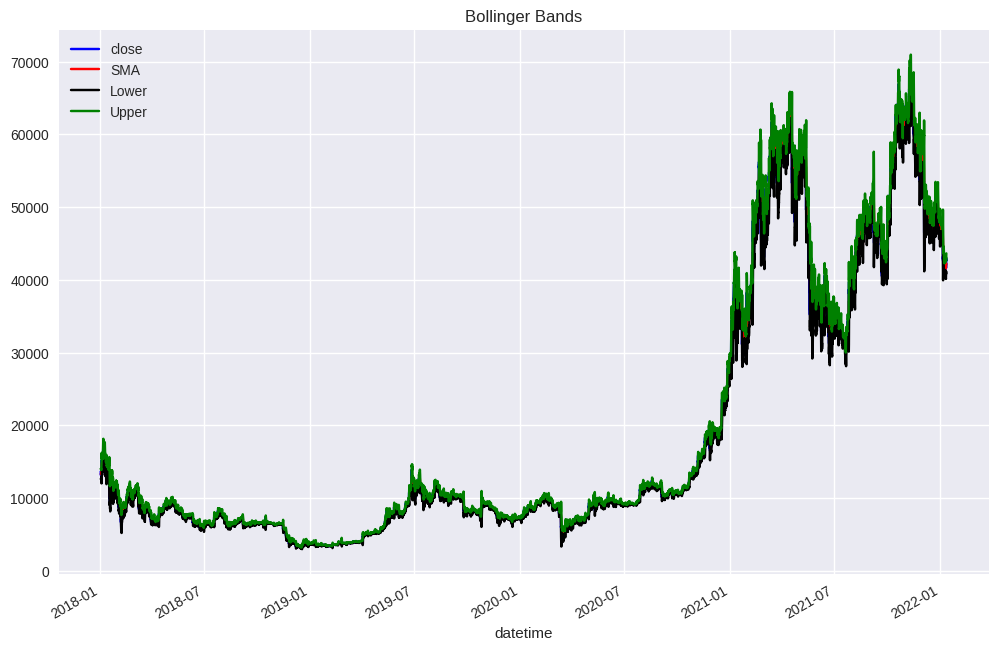

In [54]:
tester.test_bb_strategy(20,3)
tester.plot_data()

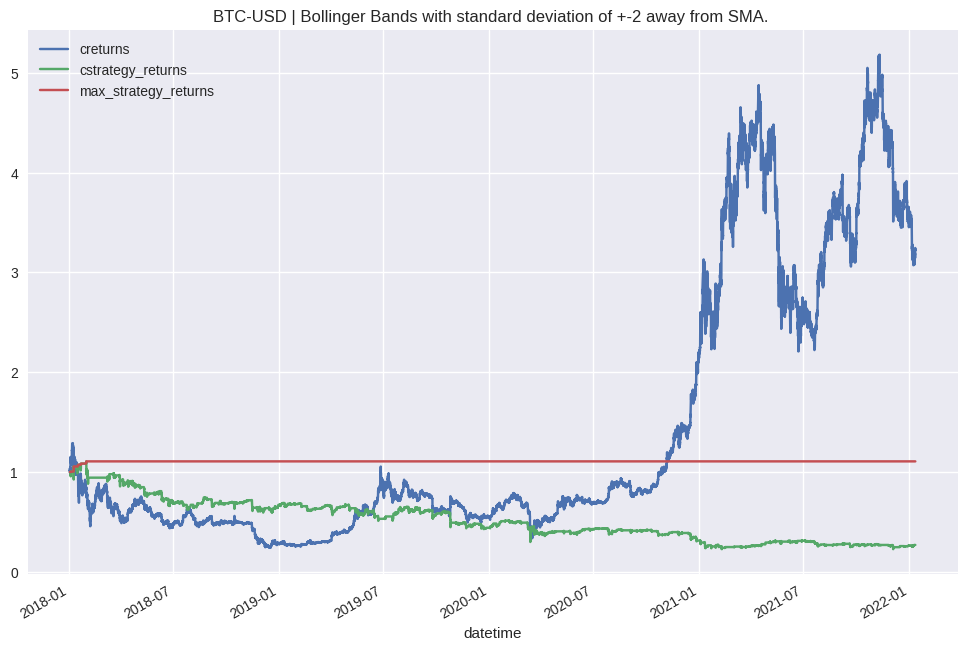

In [55]:
tester.plot_results()